In [1]:
# 1: Mount Google Drive and Load Data

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score # added: classification metrics requirement
# from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score # added: classification metrics requirement
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "/content/drive/My Drive/mbti_tune_data/"

# Load data
df = pd.read_csv(f"{DATA_PATH}/data/merged/playlist_data.csv")
print(f"✅ Loaded {len(df)} playlists")

# Load feature names
with open(f"{DATA_PATH}/features.json", 'r') as f:
    feature_cols = json.load(f)

print(f"✅ Loaded {len(feature_cols)} features")

# Display basic stats
print(f"\n📊 Personality distribution:")
print(df['personality'].value_counts())

print(f"\n📊 Dimension balance:")
for dim in ['E', 'N', 'T', 'J']:
    print(f"   {dim}: {df[dim].mean()*100:.1f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded 4201 playlists
✅ Loaded 45 features

📊 Personality distribution:
personality
INTJ    307
ESTP    306
INFJ    304
ENTP    303
ENTJ    303
ENFP    302
ENFJ    302
ISTP    300
INTP    299
INFP    295
ISFP    295
ESFP    231
ISFJ    221
ISTJ    196
ESTJ    122
ESFJ    115
Name: count, dtype: int64

📊 Dimension balance:
   E: 47.2%
   N: 57.5%
   T: 50.8%
   J: 44.5%


In [2]:
# 2: Prepare Feature Matrix and Targets

# Handle any missing values
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# Prepare X and y
X = df[feature_cols].values.astype(np.float32)
y = df[['E', 'N', 'T', 'J']].values.astype(np.float32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train/val/test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=df['personality']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=df[df.index.isin(range(len(X_temp)))]['personality'].values[:len(X_temp)]
)

print(f"\n📊 Split sizes:")
print(f"   Train: {len(X_train)}")
print(f"   Val:   {len(X_val)}")
print(f"   Test:  {len(X_test)}")

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"\n✅ Data ready for training")

X shape: (4201, 45)
y shape: (4201, 4)

📊 Split sizes:
   Train: 2940
   Val:   630
   Test:  631

✅ Data ready for training


In [3]:
# 3: Transfer Learning Architecture (Encoder + Classifier)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class AutoencoderEncoder(nn.Module):
    def __init__(self, input_dim=45):
        super(AutoencoderEncoder, self).__init__()
        # Must match the 114k Autoencoder architecture
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 16)
        )
    def forward(self, x): return self.encoder(x)

class MBTINetwork(nn.Module):
    def __init__(self, input_dim, pretrained_path=None):
        super(MBTINetwork, self).__init__()
        self.music_encoder = AutoencoderEncoder(input_dim=input_dim)
        if pretrained_path:
            # Load weights; strict=False allows random init for mismatched layers
            loaded_state_dict = torch.load(pretrained_path, map_location=device)
            new_state_dict = {f"encoder.{k}": v for k, v in loaded_state_dict.items() if not k.startswith('0.')}
            self.music_encoder.load_state_dict(new_state_dict, strict=False)
            for param in self.music_encoder.parameters(): param.requires_grad = False
            print(f"✅ Loaded pretrained encoder from {pretrained_path}")

        self.classifier = nn.Sequential(
            nn.Linear(16, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 4)
        )
    def forward(self, x): return self.classifier(self.music_encoder(x))

# Path to weights from the Autoencoder notebook
PRETRAIN_PATH = "/content/drive/My Drive/mbti_tune_data/models/encoder_114k_weights.pth"
model = MBTINetwork(input_dim=X_train.shape[1], pretrained_path=PRETRAIN_PATH).to(device)

✅ Loaded pretrained encoder from /content/drive/My Drive/mbti_tune_data/models/encoder_114k_weights.pth


In [4]:
# 4: Calculate Class Weights for Imbalance

def calculate_class_weights(y_train):
    """Calculate positive class weights for each dimension"""
    weights = []
    for i in range(4):
        n_pos = y_train[:, i].sum().item()
        n_neg = len(y_train) - n_pos
        if n_pos > 0:
            weight = n_neg / n_pos
        else:
            weight = 1.0
        weights.append(weight)
    return torch.tensor(weights, device=device)

# Convert y_train to numpy for calculation
pos_weights = calculate_class_weights(y_train)
print(f"Positive class weights (E,N,T,J):")
print(f"  E: {pos_weights[0]:.3f} (imbalance factor)")
print(f"  N: {pos_weights[1]:.3f}")
print(f"  T: {pos_weights[2]:.3f}")
print(f"  J: {pos_weights[3]:.3f}")

# Create weighted loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

Positive class weights (E,N,T,J):
  E: 1.118 (imbalance factor)
  N: 0.741
  T: 0.968
  J: 1.246


In [5]:
# 5: Training Loop with Fine-Tuning

def train_model(model, X_train, y_train, X_val, y_val, epochs=300, batch_size=32, lr=0.001):
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # --- UNFREEZE STRATEGY ---
        # After 50 epochs, unfreeze the encoder to allow fine-tuning
        if epoch == 50:
            for param in model.music_encoder.parameters():
                param.requires_grad = True
            print("\n🔥 Unfreezing music encoder for fine-tuning...")

        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss, all_preds, all_targets = 0, [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                val_loss += criterion(outputs, batch_y).item()
                all_preds.append(torch.sigmoid(outputs).cpu())
                all_targets.append(batch_y.cpu())

        # Metrics
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        all_preds, all_targets = torch.cat(all_preds), torch.cat(all_targets)
        accuracy = (torch.abs(all_preds - all_targets) < 0.15).float().mean().item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(accuracy)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            checkpoint_path = f"{DATA_PATH}/models/playlist_classifier_best.pth"
            torch.save(model.state_dict(), checkpoint_path)

        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {accuracy:.2%}")

    return train_losses, val_losses, val_accuracies

train_losses, val_losses, val_accuracies = train_model(model, X_train, y_train, X_val, y_val)

Epoch  25 | Train Loss: 0.6728 | Val Loss: 0.6624 | Acc: 0.00%
Epoch  50 | Train Loss: 0.6740 | Val Loss: 0.6599 | Acc: 0.00%

🔥 Unfreezing music encoder for fine-tuning...
Epoch  75 | Train Loss: 0.5421 | Val Loss: 0.6067 | Acc: 14.17%
Epoch 100 | Train Loss: 0.4873 | Val Loss: 0.6272 | Acc: 20.91%
Epoch 125 | Train Loss: 0.4658 | Val Loss: 0.6311 | Acc: 22.50%
Epoch 150 | Train Loss: 0.4614 | Val Loss: 0.6319 | Acc: 24.60%
Epoch 175 | Train Loss: 0.4546 | Val Loss: 0.6376 | Acc: 25.48%
Epoch 200 | Train Loss: 0.4475 | Val Loss: 0.6386 | Acc: 24.84%
Epoch 225 | Train Loss: 0.4530 | Val Loss: 0.6442 | Acc: 26.23%
Epoch 250 | Train Loss: 0.4494 | Val Loss: 0.6403 | Acc: 25.28%
Epoch 275 | Train Loss: 0.4439 | Val Loss: 0.6417 | Acc: 26.03%
Epoch 300 | Train Loss: 0.4505 | Val Loss: 0.6439 | Acc: 26.19%


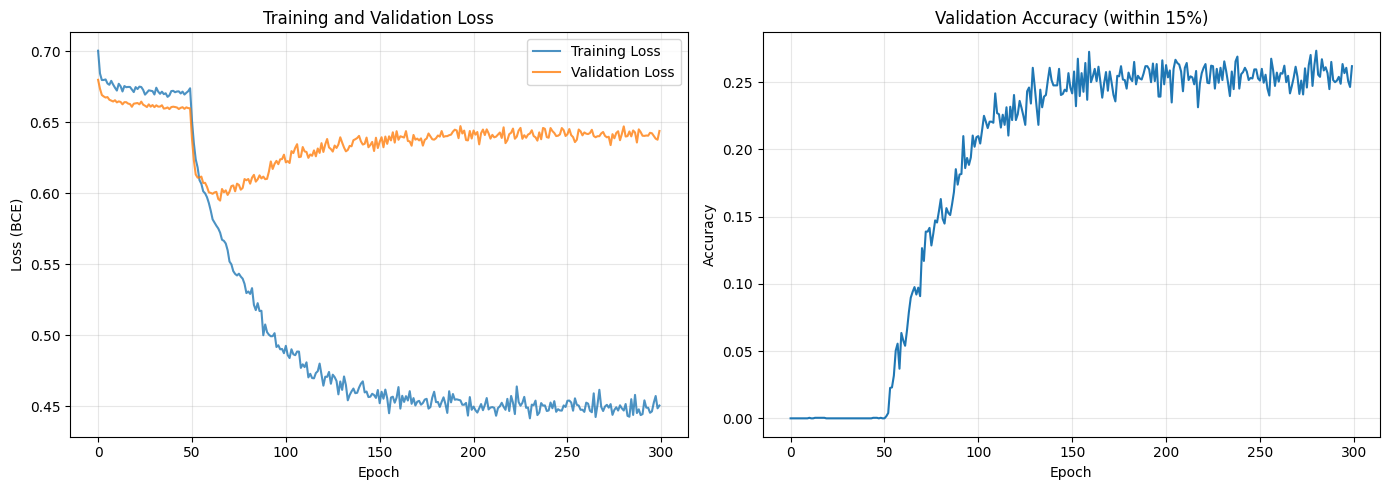

Final validation accuracy: 26.19%


In [6]:
# 6: Visualize Training Progress

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Training Loss', alpha=0.8)
axes[0].plot(val_losses, label='Validation Loss', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(val_accuracies)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy (within 15%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final validation accuracy: {val_accuracies[-1]:.2%}")

In [7]:
# 7: Test Set Evaluation

BEST_MODEL_PATH = f"{DATA_PATH}/models/playlist_classifier_best.pth"
model.load_state_dict(torch.load(BEST_MODEL_PATH))

model.eval()
with torch.no_grad():
    X_test_device = X_test.to(device)
    outputs = model(X_test_device)
    # Ensure raw logits are converted to probabilities for MAE/R2
    predictions = torch.sigmoid(outputs).cpu().numpy()
    targets = y_test.numpy()

dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']
dim_letters = ['E', 'N', 'T', 'J']

print("="*60)
print("TEST SET RESULTS")
print("="*60)

results = {}
for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    mae = mean_absolute_error(targets[:, i], predictions[:, i])
    r2 = r2_score(targets[:, i], predictions[:, i])
    results[letter] = {'mae': mae, 'r2': r2}
    print(f"\n{name} ({letter}):")
    print(f"  MAE:  {mae:.3f} ({mae*100:.1f}% avg error)")
    print(f"  R²:   {r2:.3f}")

# Overall metrics
overall_mae = mean_absolute_error(targets.flatten(), predictions.flatten())
accuracy_within_15 = (np.abs(predictions - targets) < 0.15).mean()
accuracy_within_10 = (np.abs(predictions - targets) < 0.10).mean()

print(f"\n{'='*60}")
print("OVERALL METRICS")
print(f"{'='*60}")
print(f"Overall MAE: {overall_mae:.3f} ({overall_mae*100:.1f}%)")
print(f"Accuracy (within 15%): {accuracy_within_15:.2%}")
print(f"Accuracy (within 10%): {accuracy_within_10:.2%}")
# --- OLD CODE COMMENTED OUT ---
# # (No specific classification metrics were calculated here before)

# --- ADDED: Strict grading requirement for imbalanced datasets ---
print(f"\n{'='*60}")
print("CLASSIFICATION METRICS (Threshold = 0.5) - added")
print(f"{'='*60}")
# Convert continuous percentages to binary classes (0 or 1) using 0.5 threshold
binary_preds = (predictions > 0.5).astype(int)
binary_targets = (targets > 0.5).astype(int)

for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    acc = accuracy_score(binary_targets[:, i], binary_preds[:, i])
    prec = precision_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    rec = recall_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    f1 = f1_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)

    print(f"\n{name} ({letter}):")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")

# Overall macro-averaged metrics across all 4 dimensions
macro_acc = accuracy_score(binary_targets.flatten(), binary_preds.flatten())
macro_prec = precision_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_rec = recall_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_f1 = f1_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)

print(f"\n{'='*60}")
print("MACRO-AVERAGED CLASSIFICATION METRICS - added")
print(f"{'='*60}")
print(f"Macro Accuracy:  {macro_acc:.3f}")
print(f"Macro Precision: {macro_prec:.3f}")
print(f"Macro Recall:    {macro_rec:.3f}")
print(f"Macro F1-Score:  {macro_f1:.3f}\n")

# --- OLD CODE COMMENTED OUT ---
# # (No specific classification metrics were calculated here before)

# --- ADDED: Strict grading requirement for imbalanced datasets ---
print(f"\n{'='*60}")
print("CLASSIFICATION METRICS (Threshold = 0.5) - added")
print(f"{'='*60}")
# Convert continuous percentages to binary classes (0 or 1) using 0.5 threshold
binary_preds = (predictions > 0.5).astype(int)
binary_targets = (targets > 0.5).astype(int)

for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    acc = accuracy_score(binary_targets[:, i], binary_preds[:, i])
    prec = precision_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    rec = recall_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    f1 = f1_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)

    print(f"\n{name} ({letter}):")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")

# Overall macro-averaged metrics across all 4 dimensions
macro_acc = accuracy_score(binary_targets.flatten(), binary_preds.flatten())
macro_prec = precision_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_rec = recall_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_f1 = f1_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)

print(f"\n{'='*60}")
print("MACRO-AVERAGED CLASSIFICATION METRICS - added")
print(f"{'='*60}")
print(f"Macro Accuracy:  {macro_acc:.3f}")
print(f"Macro Precision: {macro_prec:.3f}")
print(f"Macro Recall:    {macro_rec:.3f}")
print(f"Macro F1-Score:  {macro_f1:.3f}\n")


TEST SET RESULTS

Extraversion (E) (E):
  MAE:  0.346 (34.6% avg error)
  R²:   0.305

Intuition (N) (N):
  MAE:  0.465 (46.5% avg error)
  R²:   0.031

Thinking (T) (T):
  MAE:  0.353 (35.3% avg error)
  R²:   0.298

Judging (J) (J):
  MAE:  0.439 (43.9% avg error)
  R²:   0.114

OVERALL METRICS
Overall MAE: 0.401 (40.1%)
Accuracy (within 15%): 10.10%
Accuracy (within 10%): 3.37%

CLASSIFICATION METRICS (Threshold = 0.5) - added

Extraversion (E) (E):
  Accuracy:  0.761
  Precision: 0.746
  Recall:    0.748
  F1-Score:  0.747

Intuition (N) (N):
  Accuracy:  0.604
  Precision: 0.691
  Recall:    0.610
  F1-Score:  0.648

Thinking (T) (T):
  Accuracy:  0.743
  Precision: 0.775
  Recall:    0.709
  F1-Score:  0.740

Judging (J) (J):
  Accuracy:  0.650
  Precision: 0.596
  Recall:    0.607
  F1-Score:  0.602

MACRO-AVERAGED CLASSIFICATION METRICS - added
Macro Accuracy:  0.689
Macro Precision: 0.703
Macro Recall:    0.667
Macro F1-Score:  0.685


CLASSIFICATION METRICS (Threshold = 0.5) 

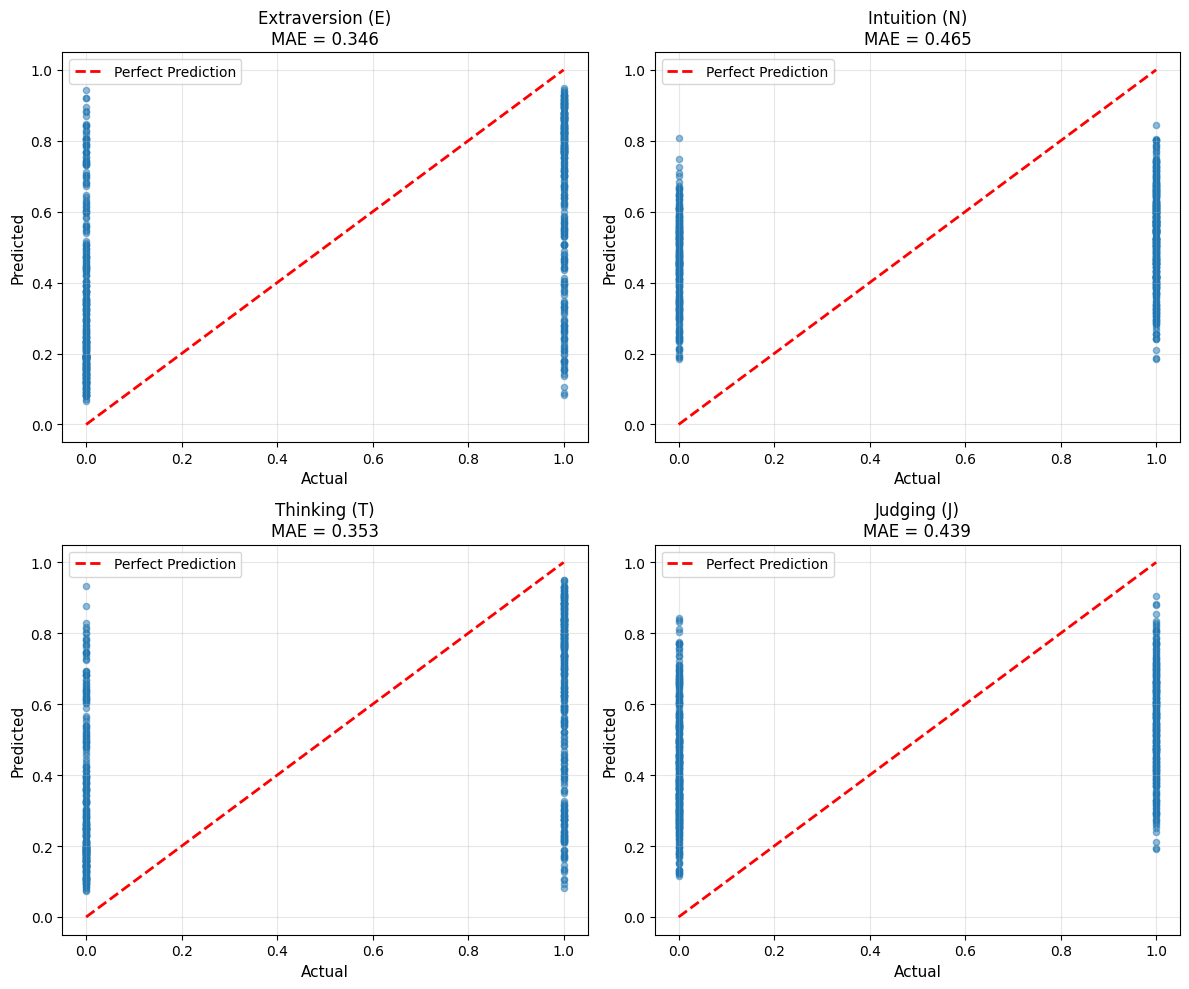

In [8]:
# 8: Predictions vs Actual Scatter Plot

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

for i, (name, ax) in enumerate(zip(dim_names, axes.flatten())):
    ax.scatter(targets[:, i], predictions[:, i], alpha=0.5, s=20)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(f'{name}\nMAE = {results[dim_letters[i]]["mae"]:.3f}', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

Initializing KernelExplainer...


  0%|          | 0/5 [00:00<?, ?it/s]


📊 Feature Impact for: Extraversion (E)


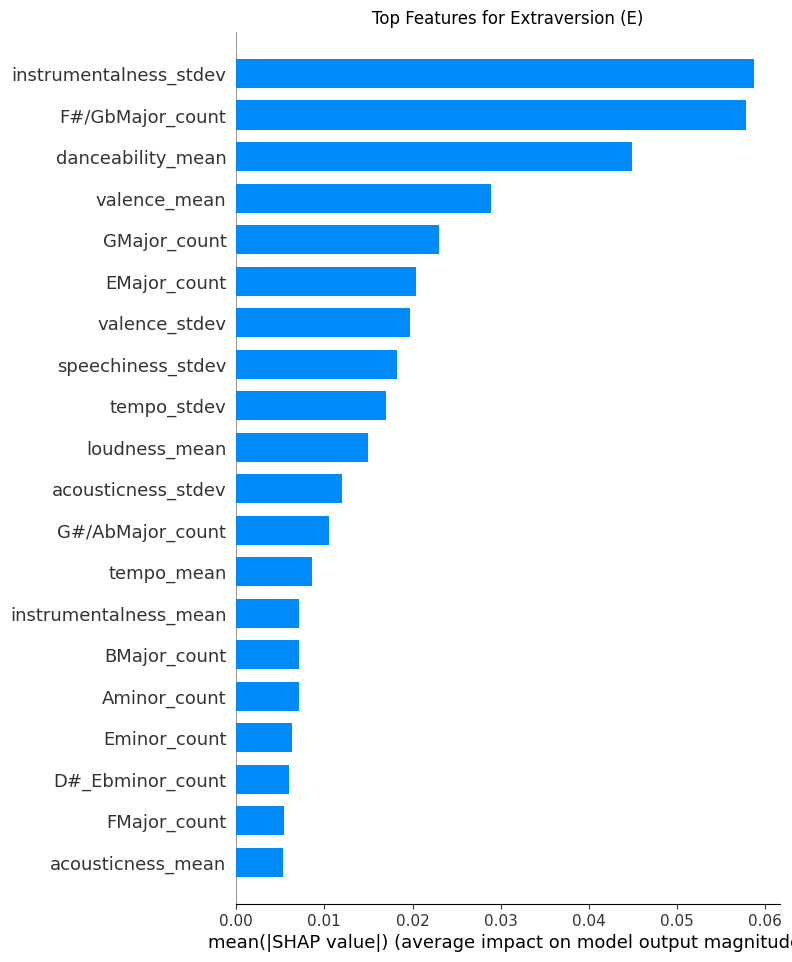


📊 Feature Impact for: Intuition (N)


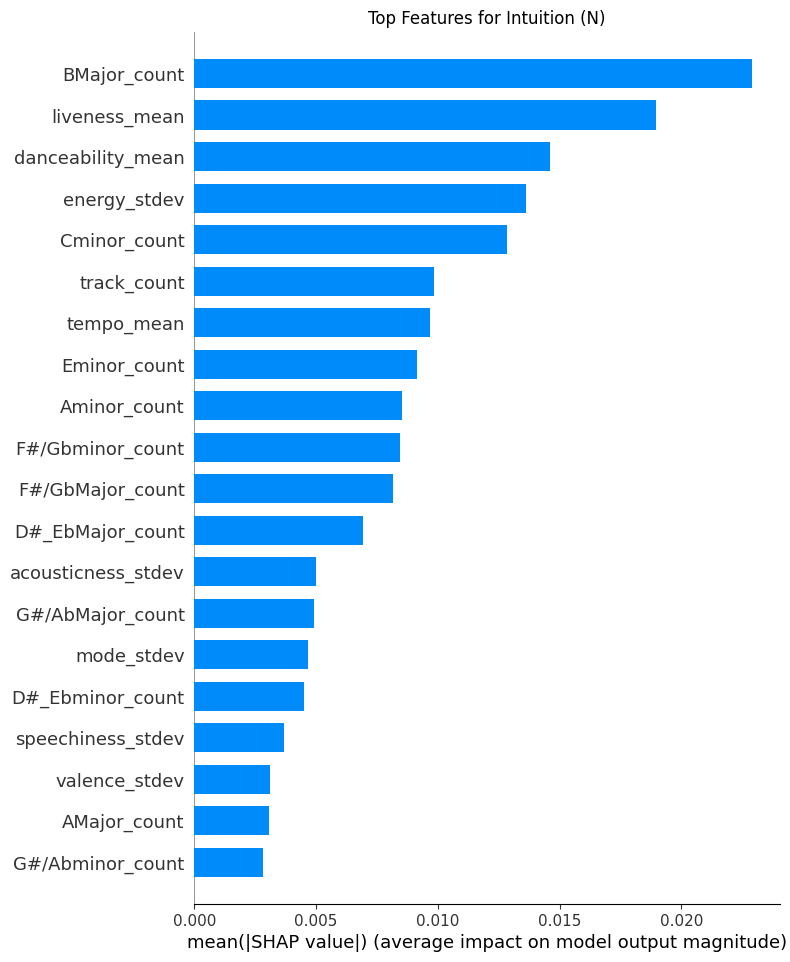


📊 Feature Impact for: Thinking (T)


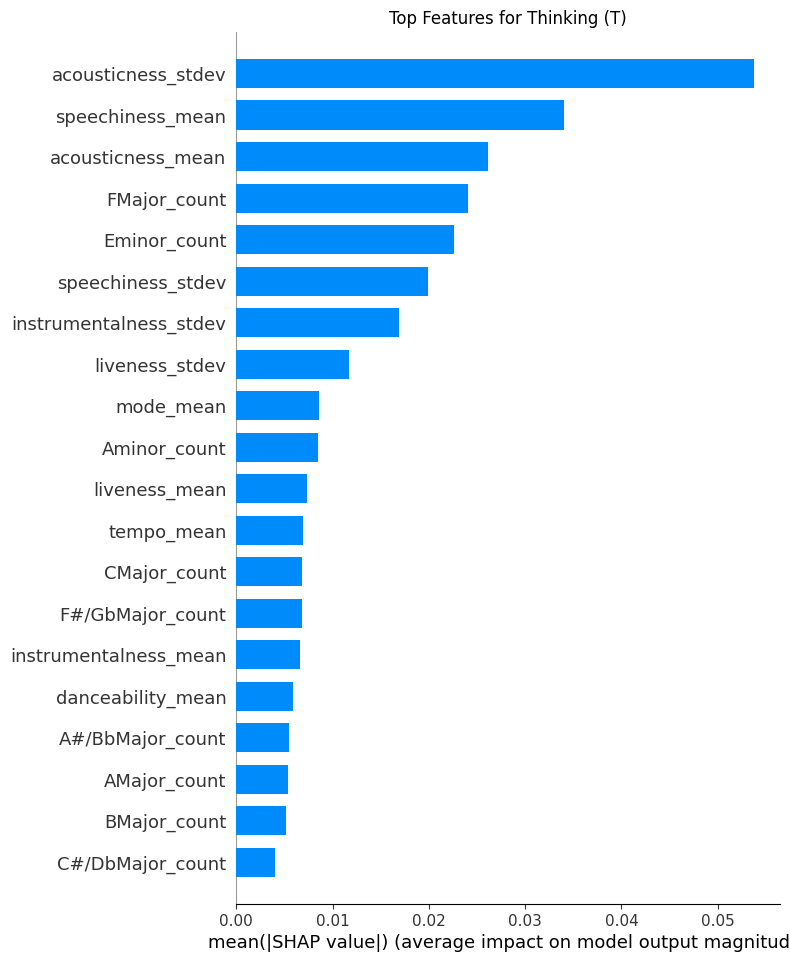


📊 Feature Impact for: Judging (J)


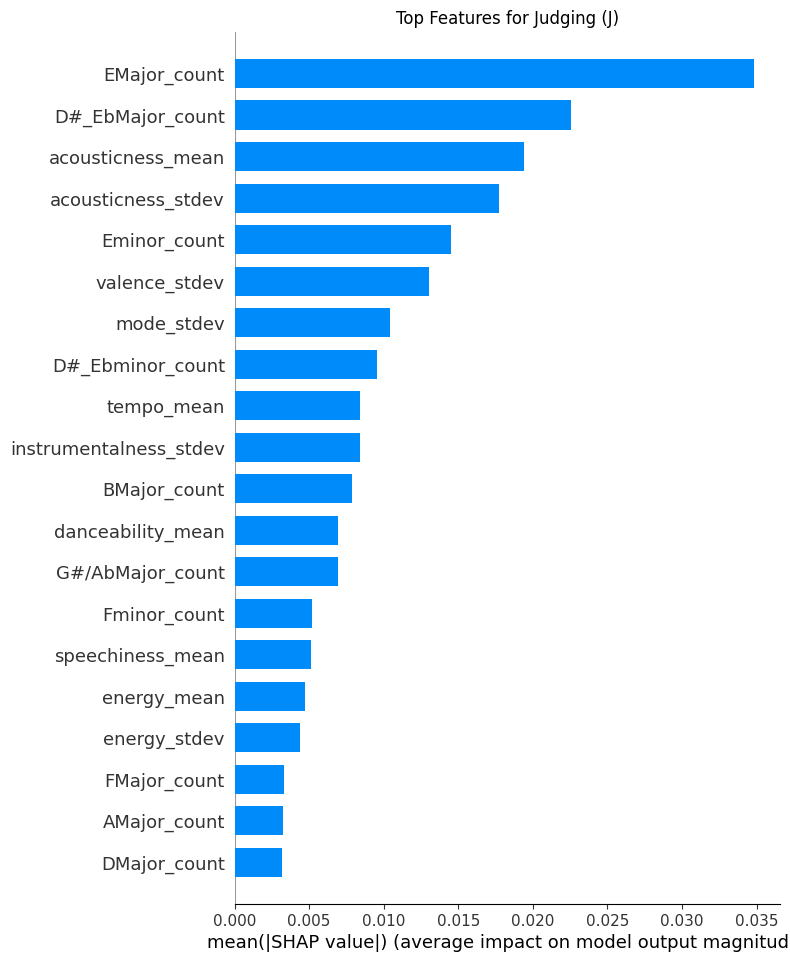

MBTINetwork(
  (music_encoder): AutoencoderEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=45, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.2, inplace=False)
      (8): Linear(in_features=64, out_features=32, bias=True)
      (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Linear(in_features=32, out_features=16, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(i

In [9]:
# 9: SHAP Explainability
import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

model.eval()
model.to('cpu')

feature_names_list = feature_cols
background = X_train[:50].cpu().numpy()
test_samples = X_test[:5].cpu().numpy()

def predict_proba_cpu(x):
    with torch.no_grad():
        x_tensor = torch.from_numpy(x).float()
        return torch.sigmoid(model(x_tensor)).numpy()

print("Initializing KernelExplainer...")
explainer = shap.KernelExplainer(predict_proba_cpu, background)
shap_values = explainer.shap_values(test_samples)

dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

# Handle cases where shap_values is a 3D array instead of a list
is_3d = isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3

for i, name in enumerate(dim_names):
    print(f"\n📊 Feature Impact for: {name}")

    # Extract the correct slice for the current dimension
    # If 3D array, shape is (samples, features, outputs) -> we need (samples, features)
    current_shap_values = shap_values[:, :, i] if is_3d else shap_values[i]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        current_shap_values,
        test_samples,
        feature_names=feature_names_list,
        plot_type="bar",
        show=False
    )
    plt.title(f"Top Features for {name}")
    plt.show()

model.to(device) # Move back to GPU